In [33]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt

In [35]:
class RadarPoseDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []

        for root, dirs, files in os.walk(root_dir):
            for f in files:
                if f.endswith("_pose.npz"):
                    base = f.replace("_pose.npz", "")
                    
                    pose_path = os.path.join(root, f)
                    radar_path = os.path.join(root, base + "_radar.npz")

                    if os.path.exists(radar_path):
                        self.samples.append((radar_path, pose_path))

        print(f"Loaded {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        radar_path, pose_path = self.samples[idx]

        # radar
        radar = np.load(radar_path)
        hori = radar["hm_hori"]
        vert = radar["hm_vert"]
        radar_input = np.stack([hori, vert], axis=0)

        # pose
        pose = np.load(pose_path)
        kp = pose["kp"][0][:, :2]  # (17,2)

        # normalize to image
        kp[:, 0] /= 640.0
        kp[:, 1] /= 480.0

        # bounding box normalization
        min_xy = kp.min(axis=0)
        max_xy = kp.max(axis=0)

        scale = max_xy - min_xy
        scale[scale == 0] = 1

        kp_norm = (kp - min_xy) / scale

        return {
            "radar": torch.tensor(radar_input, dtype=torch.float32),
            "keypoints": torch.tensor(kp_norm, dtype=torch.float32),
            "min_xy": torch.tensor(min_xy, dtype=torch.float32),
            "scale": torch.tensor(scale, dtype=torch.float32)
        }

In [36]:
dataset = RadarPoseDataset("data/P1")

Loaded 107902 samples


In [47]:
small_dataset = Subset(dataset, range(10000))
loader = DataLoader(small_dataset, batch_size=8, shuffle=True)

In [48]:
class BetterRadarPoseModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(2, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((8,8))
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),
            nn.Linear(512, 17 * 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x.view(-1, 17, 2)

In [49]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using:", device)

Using: mps


In [50]:
model = BetterRadarPoseModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

In [51]:
for epoch in range(3):
    total_loss = 0

    for batch in loader:
        radar = batch["radar"].to(device)
        gt = batch["keypoints"].to(device)

        pred = model(radar)

        loss = loss_fn(pred, gt)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}, Avg Loss: {total_loss/len(loader):.4f}")

Epoch 0, Avg Loss: 30217158.7021
Epoch 1, Avg Loss: 0.0443
Epoch 2, Avg Loss: 0.0442


In [52]:
sample = dataset[0]

radar = sample["radar"].unsqueeze(0).to(device)
gt = sample["keypoints"]
min_xy = sample["min_xy"]
scale = sample["scale"]

pred = model(radar).detach().cpu()[0]

In [53]:
# undo bbox normalization
gt_plot = gt * scale + min_xy
pred_plot = pred * scale + min_xy

# convert to pixel space
gt_plot[:,0] *= 640
gt_plot[:,1] *= 480

pred_plot[:,0] *= 640
pred_plot[:,1] *= 480

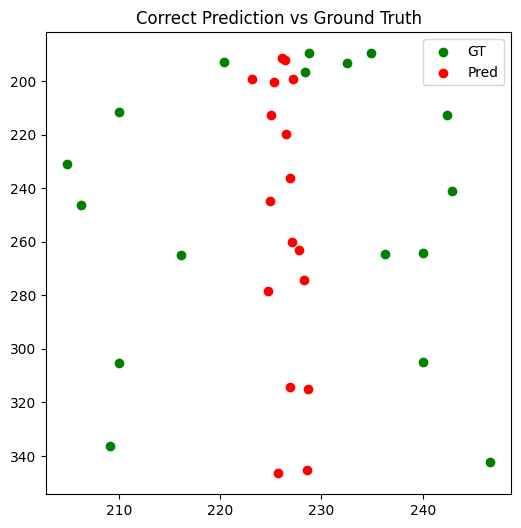

In [54]:
plt.figure(figsize=(6,6))

plt.scatter(gt_plot[:,0], gt_plot[:,1], c='g', label='GT')
plt.scatter(pred_plot[:,0], pred_plot[:,1], c='r', label='Pred')

plt.legend()
plt.title("Correct Prediction vs Ground Truth")
plt.gca().invert_yaxis()
plt.show()

In [62]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt

# ==========================================
# 1. CLEAN MULTI-VIEW RADAR DATASET
# ==========================================
class RadarPoseDataset(Dataset):
    def __init__(self, root_dir, view="both"):
        """
        view: 'both' (hori+vert), 'hori' (baseline), or 'vert'
        """
        self.samples = []
        self.view = view

        for root, dirs, files in os.walk(root_dir):
            for f in files:
                if f.endswith("_radar.npz"):
                    base_name = f.replace("_radar.npz", "")
                    radar_path = os.path.join(root, f)
                    pose_path = os.path.join(root, base_name + "_pose.npz")

                    if os.path.exists(pose_path):
                        self.samples.append((radar_path, pose_path))

        print(f"Total valid samples found: {len(self.samples)} (Mode: {self.view})")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        radar_path, pose_path = self.samples[idx]

        # 1. Load Radar based on requested view
        radar_data = np.load(radar_path)
        if self.view == "both":
            radar_input = np.stack([radar_data["hm_hori"], radar_data["hm_vert"]], axis=0) # Shape: (2, 256, 128)
        elif self.view == "hori":
            radar_input = np.expand_dims(radar_data["hm_hori"], axis=0) # Shape: (1, 256, 128)
        
        # 2. Load Pose (Ground Truth)
        pose_data = np.load(pose_path)
        kp = pose_data["kp"][0][:, :2]  # Taking first person, 17 keypoints
        
        # Normalize Keypoints to [0, 1] relative to image plane (640x480)
        kp_norm = np.copy(kp)
        kp_norm[:, 0] /= 640.0
        kp_norm[:, 1] /= 480.0

        return {
            "radar": torch.tensor(radar_input, dtype=torch.float32),
            "keypoints": torch.tensor(kp_norm, dtype=torch.float32),
            "original_kp": torch.tensor(kp, dtype=torch.float32)
        }

# ==========================================
# 2. RADAR ONLY MODEL ARCHITECTURE
# ==========================================
class RadarPoseModel(nn.Module):
    def __init__(self, in_channels=2):
        super().__init__()
        # in_channels=2 for 'both', in_channels=1 for 'hori' baseline
        
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4)) # Outputs (B, 128, 4, 4)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 17 * 2) # Predicting 17 2D Coordinates
        )

    def forward(self, radar):
        features = self.cnn(radar)
        out = self.fc(features)
        return out.view(-1, 17, 2)

# ==========================================
# 3. INITIALIZATION (Much faster now!)
# ==========================================
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
DATASET_PATH = "data/P1" 

# Primary Model Setup
full_dataset = RadarPoseDataset(DATASET_PATH, view="both")
small_dataset = Subset(full_dataset, list(range(100)))
loader = DataLoader(small_dataset, batch_size=8, shuffle=True)

primary_model = RadarPoseModel(in_channels=2).to(DEVICE)

Total valid samples found: 107902 (Mode: both)


In [63]:
# Extrinsics and Intrinsics from MMVR README
FX, FY = 379.476, 379.476
PPX, PPY = 322.457, 241.627
R_ext = np.array([[0.997214, -0.060798, -0.043211],
                  [-0.063051, -0.996610, -0.052844],
                  [0.039852, -0.055421,  0.997667]])
T_ext = np.array([[-0.064858], [0.302966], [0.091405]])

def estimate_distance_and_3d_pose(pred_2d_norm, radar_hori, radar_vert):
    """
    Extracts distance from the radar heatmaps and projects the 2D keypoints into 3D space.
    """
    # 1. FIND THE PERSON IN THE RADAR HEATMAPS
    # We find the pixel with the highest intensity (assuming it's the subject bouncing back the most signal)
    idx_d_hori, idx_a = np.unravel_index(np.argmax(radar_hori), radar_hori.shape)
    idx_d_vert, idx_e = np.unravel_index(np.argmax(radar_vert), radar_vert.shape)
    
    # 2. CONVERT RADAR PIXELS TO METERS (Using README specs)
    # Depth [0, 8]m, Azimuth [-1, 4]m, Elevation [-2, 3]m
    z_radar = (idx_d_hori / 256.0) * 8.0
    x_radar = (idx_a / 128.0) * 5.0 - 1.0
    y_radar = (idx_e / 128.0) * 5.0 - 2.0
    
    P_radar = np.array([[x_radar], [y_radar], [z_radar]])
    
    # 3. TRANSFORM RADAR 3D COORDINATES TO CAMERA 3D COORDINATES
    # Formula: P_cam = R * P_radar + t
    P_cam = R_ext @ P_radar + T_ext
    Z_cam = P_cam[2, 0] # This is the absolute Distance Estimation to the subject in meters!
    
    # 4. PROJECT 2D KEYPOINTS TO 3D SPACE
    # Convert normalized predictions [0, 1] back to pixel space [640, 480]
    u = pred_2d_norm[:, 0] * 640.0
    v = pred_2d_norm[:, 1] * 480.0
    
    # Reverse the Pinhole Camera Model projection to get X and Y in meters
    X_cam = (u - PPX) * Z_cam / FX
    Y_cam = (v - PPY) * Z_cam / FY
    
    # Combine into (17, 3) 3D keypoints
    pose_3d = np.stack((X_cam, Y_cam, np.full_like(X_cam, Z_cam)), axis=1)
    
    return pose_3d, Z_cam

# --- Test it on a single sample from your trained model ---
model.eval()
with torch.no_grad():
    sample = small_dataset[0] # Grab one sample
    
    rgb = sample["rgb"].unsqueeze(0).to(DEVICE)
    radar = sample["radar"].unsqueeze(0).to(DEVICE)
    
    # Get 2D prediction from your model
    pred_2d = model(rgb, radar).cpu().numpy()[0]
    
    # Get the raw radar numpy arrays
    radar_hori = sample["radar"][0].numpy()
    radar_vert = sample["radar"][1].numpy()
    
    # Run our Distance & 3D Estimation!
    pose_3d, estimated_distance = estimate_distance_and_3d_pose(pred_2d, radar_hori, radar_vert)
    
    print(f"Estimated Distance to Subject: {estimated_distance:.2f} meters")
    print(f"3D Coordinates of Nose (X, Y, Z in meters): {pose_3d[0]}")

KeyError: 'rgb'

In [64]:
import matplotlib.patches as patches

def visualize_pose_on_image(rgb_tensor, gt_norm, pred_norm):
    # 1. Un-normalize the RGB image so it looks normal again
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    img = inv_normalize(rgb_tensor).permute(1, 2, 0).cpu().numpy()
    img = np.clip(img, 0, 1) # Ensure values are valid colors

    # 2. Scale normalized keypoints to our 224x224 resized image
    gt_kp = gt_norm * 224.0
    pred_kp = pred_norm * 224.0

    # 3. Connections array from the MMVR README
    connections = np.array([[13, 15], [11, 13], [14, 16], [12, 14], [11, 12],
                    [5, 11], [6, 12], [5, 6], [5, 7], [6, 8], [7, 9],
                    [8, 10], [1, 2], [0, 1], [0, 2], [1, 3], [2, 4],
                    [3, 5], [4, 6]])

    plt.figure(figsize=(10, 8))
    plt.imshow(img)

    # 4. Plot Ground Truth (Green)
    for connection in connections:
        plt.plot([gt_kp[connection[0], 0], gt_kp[connection[1], 0]],
                 [gt_kp[connection[0], 1], gt_kp[connection[1], 1]], 'g-', alpha=0.8, linewidth=2)
    plt.scatter(gt_kp[:, 0], gt_kp[:, 1], c='g', s=30, label='Ground Truth')

    # 5. Plot Prediction (Red)
    for connection in connections:
        plt.plot([pred_kp[connection[0], 0], pred_kp[connection[1], 0]],
                 [pred_kp[connection[0], 1], pred_kp[connection[1], 1]], 'r-', alpha=0.8, linewidth=2)
    plt.scatter(pred_kp[:, 0], pred_kp[:, 1], c='r', s=30, label='Prediction')

    # Add distance to title
    plt.title("Pose Estimation: Green = GT | Red = Pred", fontsize=14)
    plt.axis('off')
    # Use custom legend handles to avoid duplicate labels
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    plt.show()

# --- Run the visualization on the sample we already extracted ---
model.eval()
with torch.no_grad():
    sample = small_dataset[0] 
    rgb = sample["rgb"].unsqueeze(0).to(DEVICE)
    radar = sample["radar"].unsqueeze(0).to(DEVICE)
    
    # Get predictions
    pred_2d = model(rgb, radar).cpu().numpy()[0]
    gt_2d = sample["keypoints"].numpy()
    
    visualize_pose_on_image(sample["rgb"], gt_2d, pred_2d)

KeyError: 'rgb'

Using device: mps
Loading dataset...
Starting short training test...
Epoch [1/5] - Loss: 47787676593.4461 | PCK: 0.00%
Epoch [2/5] - Loss: 0.0612 | PCK: 2.43%
Epoch [3/5] - Loss: 0.0230 | PCK: 5.71%
Epoch [4/5] - Loss: 0.0174 | PCK: 5.83%
Epoch [5/5] - Loss: 0.0162 | PCK: 10.24%


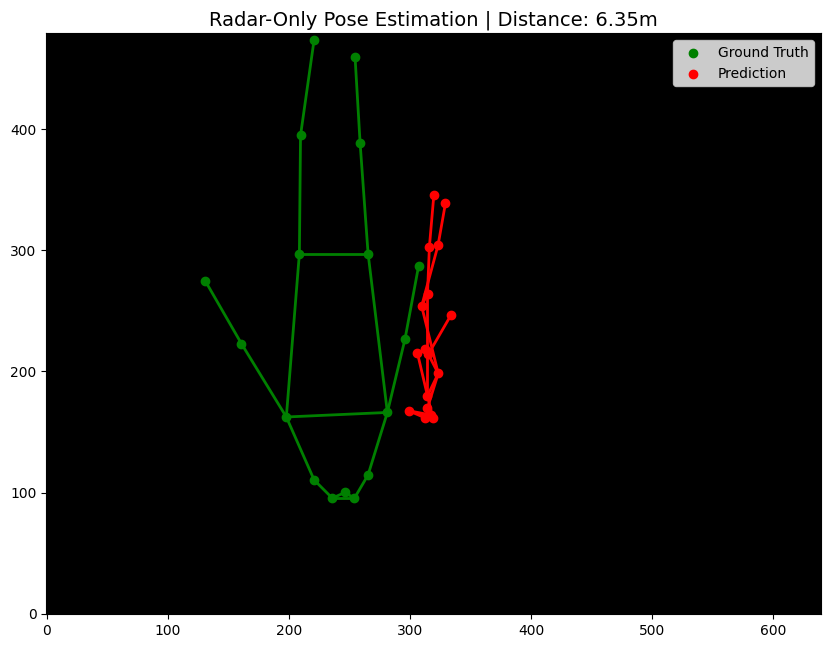

In [65]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION & CONSTANTS
# ==========================================
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Using device: {DEVICE}")

# Camera Intrinsics & Radar Extrinsics (from README)
FX, FY = 379.476, 379.476
PPX, PPY = 322.457, 241.627
R_ext = np.array([[0.997214, -0.060798, -0.043211],
                  [-0.063051, -0.996610, -0.052844],
                  [0.039852, -0.055421,  0.997667]])
T_ext = np.array([[-0.064858], [0.302966], [0.091405]])

# ==========================================
# 2. DATASET CLASS (NO RGB)
# ==========================================
class RadarPoseDataset(Dataset):
    def __init__(self, root_dir, view="both"):
        self.samples = []
        self.view = view

        for root, dirs, files in os.walk(root_dir):
            for f in files:
                if f.endswith("_radar.npz"):
                    base_name = f.replace("_radar.npz", "")
                    radar_path = os.path.join(root, f)
                    pose_path = os.path.join(root, base_name + "_pose.npz")

                    if os.path.exists(pose_path):
                        self.samples.append((radar_path, pose_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        radar_path, pose_path = self.samples[idx]

        # Load Radar based on requested view
        radar_data = np.load(radar_path)
        if self.view == "both":
            radar_input = np.stack([radar_data["hm_hori"], radar_data["hm_vert"]], axis=0) # (2, 256, 128)
        elif self.view == "hori":
            radar_input = np.expand_dims(radar_data["hm_hori"], axis=0) # (1, 256, 128)
        
        # Load Pose (Ground Truth)
        pose_data = np.load(pose_path)
        kp = pose_data["kp"][0][:, :2]  # First person, 17 keypoints
        
        # Normalize Keypoints to [0, 1] relative to image plane (640x480)
        kp_norm = np.copy(kp)
        kp_norm[:, 0] /= 640.0
        kp_norm[:, 1] /= 480.0

        return {
            "radar": torch.tensor(radar_input, dtype=torch.float32),
            "keypoints": torch.tensor(kp_norm, dtype=torch.float32)
        }

# ==========================================
# 3. RADAR MODEL ARCHITECTURE
# ==========================================
class RadarPoseModel(nn.Module):
    def __init__(self, in_channels=2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 17 * 2)
        )

    def forward(self, radar):
        features = self.cnn(radar)
        out = self.fc(features)
        return out.view(-1, 17, 2)

# ==========================================
# 4. METRICS & DISTANCE MATH
# ==========================================
def calculate_pck(pred, gt, threshold=0.05):
    distances = torch.norm(pred - gt, dim=2)
    correct_keypoints = (distances < threshold).float()
    return correct_keypoints.mean().item() * 100.0

def estimate_distance(pred_2d_norm, radar_hori, radar_vert):
    idx_d_hori, idx_a = np.unravel_index(np.argmax(radar_hori), radar_hori.shape)
    idx_d_vert, idx_e = np.unravel_index(np.argmax(radar_vert), radar_vert.shape)
    
    z_radar = (idx_d_hori / 256.0) * 8.0
    x_radar = (idx_a / 128.0) * 5.0 - 1.0
    y_radar = (idx_e / 128.0) * 5.0 - 2.0
    
    P_radar = np.array([[x_radar], [y_radar], [z_radar]])
    P_cam = R_ext @ P_radar + T_ext
    Z_cam = P_cam[2, 0] # Distance in meters
    return Z_cam

# ==========================================
# 5. INITIALIZATION & TRAINING
# ==========================================
DATASET_PATH = "data/P1" # Make sure this points to your P1 folder

print("Loading dataset...")
full_dataset = RadarPoseDataset(DATASET_PATH, view="both")
small_dataset = Subset(full_dataset, list(range(100))) # Testing with 100 samples
loader = DataLoader(small_dataset, batch_size=8, shuffle=True)

model = RadarPoseModel(in_channels=2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

print("Starting short training test...")
EPOCHS = 5
for epoch in range(EPOCHS):
    model.train()
    total_loss, total_pck = 0, 0

    for batch in loader:
        radar = batch["radar"].to(DEVICE)
        gt = batch["keypoints"].to(DEVICE)

        pred = model(radar)
        loss = criterion(pred, gt)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_pck += calculate_pck(pred.detach(), gt.detach())

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {total_loss/len(loader):.4f} | PCK: {total_pck/len(loader):.2f}%")

# ==========================================
# 6. VISUALIZATION ON BLANK BACKGROUND
# ==========================================
model.eval()
with torch.no_grad():
    sample = small_dataset[0]
    radar = sample["radar"].unsqueeze(0).to(DEVICE)
    pred_2d = model(radar).cpu().numpy()[0]
    gt_2d = sample["keypoints"].numpy()
    
    # Run distance estimation
    radar_hori = sample["radar"][0].numpy()
    radar_vert = sample["radar"][1].numpy()
    dist = estimate_distance(pred_2d, radar_hori, radar_vert)

    # Scale coordinates back to 640x480
    pred_kp = pred_2d * np.array([640.0, 480.0])
    gt_kp = gt_2d * np.array([640.0, 480.0])

    connections = np.array([[13, 15], [11, 13], [14, 16], [12, 14], [11, 12],
                    [5, 11], [6, 12], [5, 6], [5, 7], [6, 8], [7, 9],
                    [8, 10], [1, 2], [0, 1], [0, 2], [1, 3], [2, 4],
                    [3, 5], [4, 6]])

    # Draw on black background (like the dataset creators did)
    img = np.zeros((480, 640, 3), dtype=np.uint8)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Radar-Only Pose Estimation | Distance: {dist:.2f}m", fontsize=14)

    # Plot Ground Truth (Green)
    for c in connections:
        plt.plot([gt_kp[c[0], 0], gt_kp[c[1], 0]], [gt_kp[c[0], 1], gt_kp[c[1], 1]], 'g-', linewidth=2)
    plt.scatter(gt_kp[:, 0], gt_kp[:, 1], c='g', label='Ground Truth')

    # Plot Prediction (Red)
    for c in connections:
        plt.plot([pred_kp[c[0], 0], pred_kp[c[1], 0]], [pred_kp[c[0], 1], pred_kp[c[1], 1]], 'r-', linewidth=2)
    plt.scatter(pred_kp[:, 0], pred_kp[:, 1], c='r', label='Prediction')

    # Formatting legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    plt.gca().invert_yaxis() # Invert Y axis so skeleton isn't upside down!
    plt.show()

Using device: mps
Loading full dataset...
Training on 86321 samples. Validating on 21581 samples.
Starting FULL training...
Epoch [1/15] | Train Loss: 285233440.4705, Train PCK: 10.35% | Val Loss: 0.0118, Val PCK: 21.93%
Epoch [2/15] | Train Loss: 0.0178, Train PCK: 10.61% | Val Loss: 0.0111, Val PCK: 26.77%
Epoch [3/15] | Train Loss: 0.0178, Train PCK: 10.58% | Val Loss: 0.0120, Val PCK: 18.65%
Epoch [4/15] | Train Loss: 0.0177, Train PCK: 10.67% | Val Loss: 0.0111, Val PCK: 24.76%
Epoch [5/15] | Train Loss: 0.0175, Train PCK: 10.88% | Val Loss: 0.0111, Val PCK: 24.55%
Epoch [6/15] | Train Loss: 0.0170, Train PCK: 11.21% | Val Loss: 0.0111, Val PCK: 26.12%
Epoch [7/15] | Train Loss: 0.0167, Train PCK: 11.33% | Val Loss: 0.0117, Val PCK: 21.49%
Epoch [8/15] | Train Loss: 0.0159, Train PCK: 12.06% | Val Loss: 0.0111, Val PCK: 24.10%
Epoch [9/15] | Train Loss: 0.0141, Train PCK: 14.18% | Val Loss: 0.0111, Val PCK: 23.02%
Epoch [10/15] | Train Loss: 0.0122, Train PCK: 19.06% | Val Loss: 0

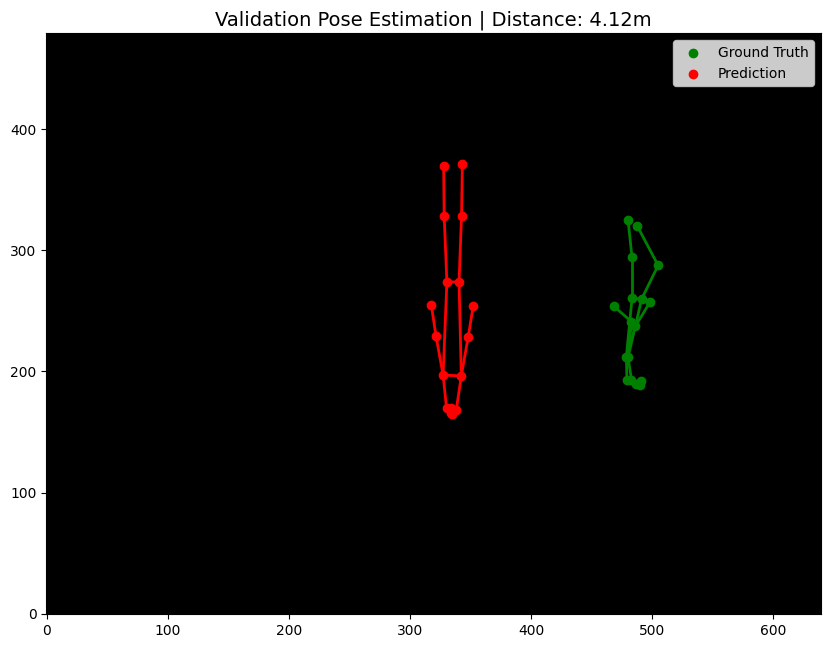

In [66]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION & CONSTANTS
# ==========================================
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Using device: {DEVICE}")

# Camera Intrinsics & Radar Extrinsics (from README)
FX, FY = 379.476, 379.476
PPX, PPY = 322.457, 241.627
R_ext = np.array([[0.997214, -0.060798, -0.043211],
                  [-0.063051, -0.996610, -0.052844],
                  [0.039852, -0.055421,  0.997667]])
T_ext = np.array([[-0.064858], [0.302966], [0.091405]])

# ==========================================
# 2. DATASET CLASS 
# ==========================================
class RadarPoseDataset(Dataset):
    def __init__(self, root_dir, view="both"):
        self.samples = []
        self.view = view

        for root, dirs, files in os.walk(root_dir):
            for f in files:
                if f.endswith("_radar.npz"):
                    base_name = f.replace("_radar.npz", "")
                    radar_path = os.path.join(root, f)
                    pose_path = os.path.join(root, base_name + "_pose.npz")

                    if os.path.exists(pose_path):
                        self.samples.append((radar_path, pose_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        radar_path, pose_path = self.samples[idx]

        # Load Radar based on requested view
        radar_data = np.load(radar_path)
        if self.view == "both":
            radar_input = np.stack([radar_data["hm_hori"], radar_data["hm_vert"]], axis=0) # (2, 256, 128)
        elif self.view == "hori":
            radar_input = np.expand_dims(radar_data["hm_hori"], axis=0) # (1, 256, 128)
        
        # Load Pose (Ground Truth)
        pose_data = np.load(pose_path)
        kp = pose_data["kp"][0][:, :2]  # First person, 17 keypoints
        
        # Normalize Keypoints to [0, 1] relative to image plane (640x480)
        kp_norm = np.copy(kp)
        kp_norm[:, 0] /= 640.0
        kp_norm[:, 1] /= 480.0

        return {
            "radar": torch.tensor(radar_input, dtype=torch.float32),
            "keypoints": torch.tensor(kp_norm, dtype=torch.float32),
            "original_kp": torch.tensor(kp, dtype=torch.float32)
        }

# ==========================================
# 3. RADAR MODEL ARCHITECTURE
# ==========================================
class RadarPoseModel(nn.Module):
    def __init__(self, in_channels=2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 17 * 2)
        )

    def forward(self, radar):
        features = self.cnn(radar)
        out = self.fc(features)
        return out.view(-1, 17, 2)

# ==========================================
# 4. METRICS & DISTANCE MATH
# ==========================================
def calculate_pck(pred, gt, threshold=0.05):
    distances = torch.norm(pred - gt, dim=2)
    correct_keypoints = (distances < threshold).float()
    return correct_keypoints.mean().item() * 100.0

def estimate_distance(pred_2d_norm, radar_hori, radar_vert):
    idx_d_hori, idx_a = np.unravel_index(np.argmax(radar_hori), radar_hori.shape)
    idx_d_vert, idx_e = np.unravel_index(np.argmax(radar_vert), radar_vert.shape)
    
    z_radar = (idx_d_hori / 256.0) * 8.0
    x_radar = (idx_a / 128.0) * 5.0 - 1.0
    y_radar = (idx_e / 128.0) * 5.0 - 2.0
    
    P_radar = np.array([[x_radar], [y_radar], [z_radar]])
    P_cam = R_ext @ P_radar + T_ext
    Z_cam = P_cam[2, 0] # Distance in meters
    return Z_cam

# ==========================================
# 5. FULL INITIALIZATION & TRAINING
# ==========================================
DATASET_PATH = "data/P1" # Make sure this points to your P1 folder

print("Loading full dataset...")
full_dataset = RadarPoseDataset(DATASET_PATH, view="both")

# Standard 80/20 Train/Validation Split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Training on {train_size} samples. Validating on {val_size} samples.")

# Using larger batch size since we have lots of data
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Initialize Model
model = RadarPoseModel(in_channels=2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

print("Starting FULL training...")
EPOCHS = 15 # Adjust this higher if you have time, or lower if it's too slow

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    train_loss, train_pck = 0, 0

    for batch in train_loader:
        radar = batch["radar"].to(DEVICE)
        gt = batch["keypoints"].to(DEVICE)

        pred = model(radar)
        loss = criterion(pred, gt)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_pck += calculate_pck(pred.detach(), gt.detach())

    avg_train_loss = train_loss / len(train_loader)
    avg_train_pck = train_pck / len(train_loader)

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, val_pck = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            radar = batch["radar"].to(DEVICE)
            gt = batch["keypoints"].to(DEVICE)
            
            pred = model(radar)
            loss = criterion(pred, gt)
            
            val_loss += loss.item()
            val_pck += calculate_pck(pred, gt)
            
    avg_val_loss = val_loss / len(val_loader)
    avg_val_pck = val_pck / len(val_loader)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {avg_train_loss:.4f}, Train PCK: {avg_train_pck:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Val PCK: {avg_val_pck:.2f}%")

# Save the trained model weights for your report!
torch.save(model.state_dict(), "best_radar_pose_model.pth")
print("Training complete and model saved!")

# ==========================================
# 6. VISUALIZATION ON UNSEEN VALIDATION DATA
# ==========================================
model.eval()
with torch.no_grad():
    sample = val_dataset[0] # Grab the first UNSEEN sample from validation
    radar = sample["radar"].unsqueeze(0).to(DEVICE)
    pred_2d = model(radar).cpu().numpy()[0]
    gt_2d = sample["keypoints"].numpy()
    
    # Run distance estimation
    radar_hori = sample["radar"][0].numpy()
    radar_vert = sample["radar"][1].numpy()
    dist = estimate_distance(pred_2d, radar_hori, radar_vert)

    # Scale coordinates back to 640x480
    pred_kp = pred_2d * np.array([640.0, 480.0])
    gt_kp = gt_2d * np.array([640.0, 480.0])

    connections = np.array([[13, 15], [11, 13], [14, 16], [12, 14], [11, 12],
                    [5, 11], [6, 12], [5, 6], [5, 7], [6, 8], [7, 9],
                    [8, 10], [1, 2], [0, 1], [0, 2], [1, 3], [2, 4],
                    [3, 5], [4, 6]])

    # Draw on black background
    img = np.zeros((480, 640, 3), dtype=np.uint8)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Validation Pose Estimation | Distance: {dist:.2f}m", fontsize=14)

    # Plot Ground Truth (Green)
    for c in connections:
        plt.plot([gt_kp[c[0], 0], gt_kp[c[1], 0]], [gt_kp[c[0], 1], gt_kp[c[1], 1]], 'g-', linewidth=2)
    plt.scatter(gt_kp[:, 0], gt_kp[:, 1], c='g', label='Ground Truth')

    # Plot Prediction (Red)
    for c in connections:
        plt.plot([pred_kp[c[0], 0], pred_kp[c[1], 0]], [pred_kp[c[0], 1], pred_kp[c[1], 1]], 'r-', linewidth=2)
    plt.scatter(pred_kp[:, 0], pred_kp[:, 1], c='r', label='Prediction')

    # Formatting legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    plt.gca().invert_yaxis() 
    plt.show()

In [68]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. Find the very first pose file in your dataset
pose_path = None
for root, dirs, files in os.walk("data/P1"):
    for f in files:
        if f.endswith("_pose.npz"):
            pose_path = os.path.join(root, f)
            break
    if pose_path: break

# 2. Inspect what is actually inside this file
pose_data = np.load(pose_path)
print(f"Keys hidden inside the pose file: {pose_data.files}")

# 3. Let's try to draw 'kp_2d' instead of 'kp'
if "kp_2d" in pose_data.files:
    kp_2d = pose_data["kp_2d"][0][:, :2] # Grab 2D pixel coordinates directly
    
    # Draw it!
    img = np.zeros((480, 640, 3), dtype=np.uint8)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title("Ground Truth Sanity Check (kp_2d)", fontsize=14)

    connections = np.array([[13, 15], [11, 13], [14, 16], [12, 14], [11, 12],
                    [5, 11], [6, 12], [5, 6], [5, 7], [6, 8], [7, 9],
                    [8, 10], [1, 2], [0, 1], [0, 2], [1, 3], [2, 4],
                    [3, 5], [4, 6]])

    for c in connections:
        plt.plot([kp_2d[c[0], 0], kp_2d[c[1], 0]], [kp_2d[c[0], 1], kp_2d[c[1], 1]], 'g-', linewidth=2)
    plt.scatter(kp_2d[:, 0], kp_2d[:, 1], c='g')
    
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("Uh oh, 'kp_2d' is not in the file. We need to look at the keys printed above!")

Keys hidden inside the pose file: ['kp']
Uh oh, 'kp_2d' is not in the file. We need to look at the keys printed above!


Raw Keypoint Coordinates (Notice the 0s for hidden joints!):
[[232.57812 193.35938]
 [234.92188 189.60938]
 [228.82812 189.60938]
 [228.35938 196.64062]
 [220.39062 192.89062]
 [242.42188 212.57812]
 [210.07812 211.64062]
 [242.89062 241.17188]
 [204.92188 230.85938]
 [240.07812 264.14062]
 [206.32812 246.32812]
 [236.32812 264.60938]
 [216.17188 265.07812]
 [240.07812 304.92188]
 [210.07812 305.39062]
 [246.64062 342.42188]
 [209.14062 336.32812]]


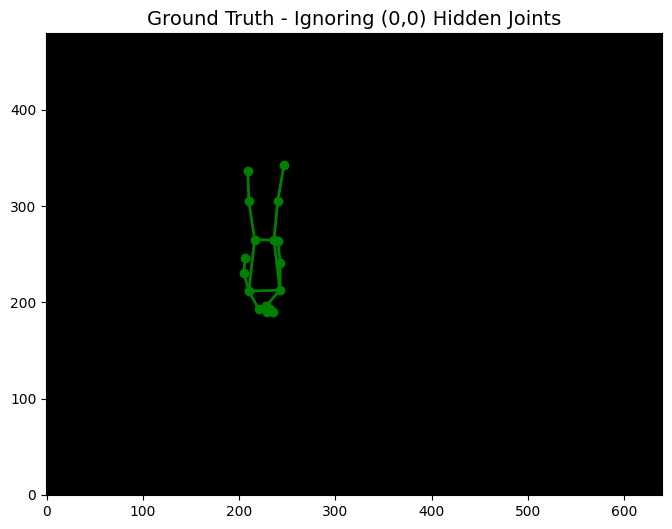

In [69]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. Find the first pose file
pose_path = None
for root, dirs, files in os.walk("data/P1"):
    if pose_path: break
    for f in files:
        if f.endswith("_pose.npz"):
            pose_path = os.path.join(root, f)
            break

# 2. Load the data
pose_data = np.load(pose_path)
kp_raw = pose_data["kp"][0][:, :2] # Grab the first person's 17 keypoints

print("Raw Keypoint Coordinates (Notice the 0s for hidden joints!):")
print(kp_raw)

# 3. Draw it safely (ignoring 0,0)
img = np.zeros((480, 640, 3), dtype=np.uint8)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title("Ground Truth - Ignoring (0,0) Hidden Joints", fontsize=14)

connections = np.array([[13, 15], [11, 13], [14, 16], [12, 14], [11, 12],
                [5, 11], [6, 12], [5, 6], [5, 7], [6, 8], [7, 9],
                [8, 10], [1, 2], [0, 1], [0, 2], [1, 3], [2, 4],
                [3, 5], [4, 6]])

# Only draw lines if BOTH points are not (0,0)
for c in connections:
    p1, p2 = kp_raw[c[0]], kp_raw[c[1]]
    if (p1[0] != 0 or p1[1] != 0) and (p2[0] != 0 or p2[1] != 0):
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'g-', linewidth=2)

# Only scatter points that are not (0,0)
valid_kps = np.array([p for p in kp_raw if p[0] != 0 or p[1] != 0])
if len(valid_kps) > 0:
    plt.scatter(valid_kps[:, 0], valid_kps[:, 1], c='g')
    
plt.gca().invert_yaxis()
plt.show()